In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle

In [9]:
df = pd.read_csv("student_data.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [10]:
print(df.head())

   Study_Hours  Attendance  Assignment  Internal_Marks Final_Grade
0            7          69          46               5           C
1            4          69          99               8           B
2            8          80          55              19           A
3            5          96          65              17           B
4            7          67          87               9           B


In [11]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (120, 5)

Missing Values:
Study_Hours       0
Attendance        0
Assignment        0
Internal_Marks    0
Final_Grade       0
dtype: int64


In [12]:
print(df.describe())

       Study_Hours  Attendance  Assignment  Internal_Marks
count   120.000000  120.000000  120.000000      120.000000
mean      5.766667   77.933333   72.133333       12.650000
std       2.866009   13.379863   17.131196        4.743239
min       1.000000   55.000000   40.000000        5.000000
25%       3.000000   66.750000   59.000000        8.750000
50%       6.000000   80.000000   72.500000       12.500000
75%       8.000000   88.250000   87.000000       17.000000
max      10.000000   99.000000  100.000000       20.000000


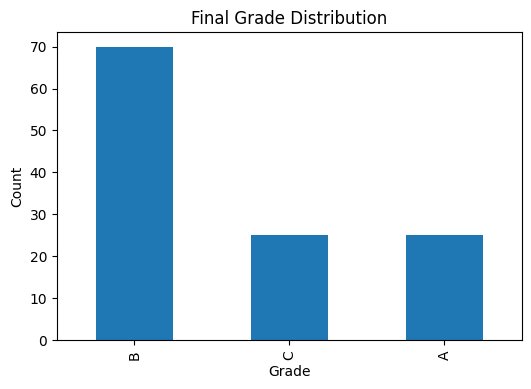

In [13]:
plt.figure(figsize=(6,4))

df["Final_Grade"].value_counts().plot(kind="bar")

plt.title("Final Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")

plt.show()

In [14]:
X = df[[
    "Study_Hours",
    "Attendance",
    "Assignment",
    "Internal_Marks"
]]

y = df["Final_Grade"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = RandomForestClassifier(
    random_state=42
)

In [17]:
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [18]:
predictions = model.predict(X_test)

print(predictions[:10])

['B' 'B' 'B' 'B' 'B' 'C' 'B' 'B' 'A' 'B']


In [19]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    round(accuracy*100,2),
    "%"
)

Accuracy: 75.0 %


In [20]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           A       0.67      0.67      0.67         3
           B       0.69      0.92      0.79        12
           C       1.00      0.56      0.71         9

    accuracy                           0.75        24
   macro avg       0.78      0.71      0.72        24
weighted avg       0.80      0.75      0.74        24



In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(
    importance.sort_values(
        by="Importance",
        ascending=False
    )
)

          Feature  Importance
0     Study_Hours    0.336825
3  Internal_Marks    0.322997
2      Assignment    0.200210
1      Attendance    0.139968


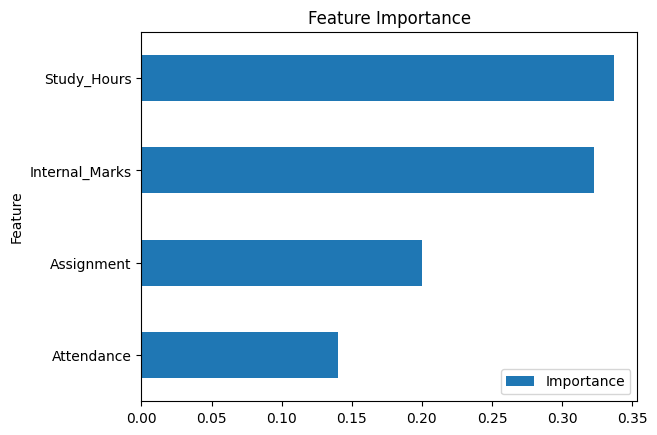

In [22]:
importance.sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Feature Importance")

plt.show()

In [23]:
with open(
    "student_model.pkl",
    "wb"
) as model_file:

    pickle.dump(
        model,
        model_file
    )

print("Model Saved")

Model Saved
